In [1]:
from spyral.core.constants import AMU_2_MEV, QBRHO_2_P

from spyral_utils.nuclear import NuclearDataMap
from spyral_utils.nuclear.target import GasTarget, load_target
from spyral_utils.plot import Histogrammer
from spyral.core.run_stacks import form_run_string

from KinematicPlotter import plot_kinematics

import polars as pl
import numpy as np
from pathlib import Path, WindowsPath
import matplotlib.pyplot as plt
import vector
from scipy.constants import physical_constants, torr

%matplotlib widget
plt.close("all")

# Experimental Data

In [2]:
solver_result_path = WindowsPath("D:/a2091/Workspace_d/InterpSolver/")
target_material_path = WindowsPath("C:/Users/NateM/WorkStuff/Analysis/a2091/GasParams_d.json")

# Run number range (inclusive)
run_min = 17
run_max = 133

# The nucleus we observe (the one we fitted)
ejectile_z = 1
ejectile_a = 3

# The incoming nucleus (the beam)
projectile_z = 6
projectile_a = 15

# The target nucleus
target_z = 1
target_a = 2

residual_z = target_z + projectile_z - ejectile_z
residual_a = target_a + projectile_a - ejectile_a

if residual_z < 0:
    raise Exception(f"Illegal nuclei! Residual Z: {residual_z}")
if residual_a < 1:
    raise Exception(f"Illegal nuclei! Residual A: {residual_a}")

In [3]:
ic_min_val = 1000.0
ic_max_val = 1250.0

min_z = 0.005
max_z = 0.995

min_cm = 0.0
max_cm = 90.0

ex_energy_min = -5.0
ex_energy_max = 12.0
ex_energy_bins = 85

ex_en_min = 6.72
ex_en_max = 7.29

ang_dist_bins = 20 #40

In [4]:
boltzmann = physical_constants["Boltzmann constant"][0]    # Units of Joules / Kelvin
torr_2_pascal = torr    # Convert from torr to pascals
pressure = 300 # Units of Torr
temperature = 273.15    # Units of Kelvin, STP
stoich = 2 # Stoichiometry of gas

In [5]:
nuclear_map = NuclearDataMap()

target_material = load_target(target_material_path, nuclear_map)
if not isinstance(target_material, GasTarget):
    print('Target error!')

ejectile = nuclear_map.get_data(ejectile_z, ejectile_a)
projectile = nuclear_map.get_data(projectile_z, projectile_a)
target = nuclear_map.get_data(target_z, target_a)
residual = nuclear_map.get_data(residual_z, residual_a)
print(f"Reaction: {target}({projectile}, {ejectile}){residual}")

# Initial beam energy
mass_amu = projectile.mass / AMU_2_MEV
#proj_energy_start = 11.5 * mass_amu #MeV
proj_energy_start = 186.055
proj_energy_stop = proj_energy_start - target_material.get_energy_loss(projectile, proj_energy_start, np.array([1.0]))[0] # Energy at far end of detector

Reaction: 2H(15C, 3H)14C


In [6]:
grammer = Histogrammer()
grammer.add_hist2d('ke_theta', (360, 1600), ((0.0, 180.0), (0.0, 80.0)))
grammer.add_hist2d('ke_phi', (360, 1600), ((0.0, 360.0), (0.0, 80.0)))
grammer.add_hist1d('ex', ex_energy_bins, (ex_energy_min, ex_energy_max))

In [7]:
results = {}
results["event"] = np.empty(0, float)
results["Polar_CM"] = np.empty(0, float)
results["Ex"] = np.empty(0, float)
results["Polar_Lab"] = np.empty(0, float)
results["KE"] = np.empty(0, float)
results["zvert"] = np.empty(0, float)
results["dEdx"] = np.empty(0, float)
results["sqrt_dEdx"] = np.empty(0, float)
results["brho"] = np.empty(0, float)

kinetics = np.empty(0, float)
angles = np.empty(0, float)
chisq = np.empty(0, float)
target_vector = vector.array({"px": [0.0], "py": [0.0], "pz": [0.0], "E": [target.mass]})

for run in range(run_min, run_max+1):
    df = None
    path = solver_result_path / f"run_{run:04d}_{ejectile.isotopic_symbol}.parquet"
    if not path.exists():
        continue
    df = pl.scan_parquet(path)

    #df = df.filter((pl.col('redchisq') < 1.65))
    df = df.filter((pl.col("vertex_z") > min_z) & (pl.col("vertex_z") < max_z)).collect()
    
    # Construct the projectile vectors (beam)
    vertices = df.select(['vertex_x', 'vertex_y', 'vertex_z']).to_numpy()
    distances = np.linalg.norm(vertices, axis=1)
    projectile_ke = proj_energy_start - target_material.get_energy_loss(projectile, proj_energy_start, distances)
    projectile_vector = vector.array({
        "px": np.zeros(len(projectile_ke)),
        "py": np.zeros(len(projectile_ke)),
        "pz": np.sqrt(projectile_ke * (projectile_ke + 2.0 * projectile.mass)),
        "E": projectile_ke + projectile.mass
    })

    # Construct the ejectile vectors (detected)
    brho = df.select('brho').to_numpy().flatten()
    momentum = df.select('brho').to_numpy().flatten() * float(ejectile.Z) * QBRHO_2_P
    kinetic_energy = np.sqrt(momentum**2.0 + ejectile.mass**2.0) - ejectile.mass
    polar = df.select('polar').to_numpy().flatten()
    az = df.select('azimuthal').to_numpy().flatten()
    cs = df.select('redchisq').to_numpy().flatten()
    ejectile_vector = vector.array({
        "px": momentum * np.sin(polar) * np.cos(az),
        "py": momentum * np.sin(polar) * np.sin(az),
        "pz": momentum * np.cos(polar),
        "E": np.sqrt(momentum**2.0 + ejectile.mass**2.0)
    })

    # Do the kinematics
    residual_vector = target_vector + projectile_vector - ejectile_vector # type: ignore

    cm_vec = ejectile_vector.boostCM_of(projectile_vector + target_vector)
    polar_cm = np.pi - cm_vec.theta
    ex = residual_vector.mass - residual.mass

    try:
        results["event"] = np.append(results["event"], df.select("event").to_numpy().flatten())
        results["Polar_CM"] = np.append(results["Polar_CM"], polar_cm)
        results["Ex"] = np.append(results["Ex"], ex)
        results["Polar_Lab"] = np.append(results["Polar_Lab"], polar)
        results["KE"] = np.append(results["KE"], kinetic_energy)
        results["zvert"] = np.append(results["zvert"], df.select("vertex_z").to_numpy().flatten())
        results["dEdx"] = np.append(results["dEdx"], df.select("dEdx").to_numpy().flatten())
        results["sqrt_dEdx"] = np.append(results["sqrt_dEdx"], df.select("sqrt_dEdx").to_numpy().flatten())
        results["brho"] = np.append(results["brho"], df.select("brho").to_numpy().flatten())
    except:
        print(f"There was an error with run: {run}")
        pass


Overwriting histogram named ex in Histogrammer.add_histogram!


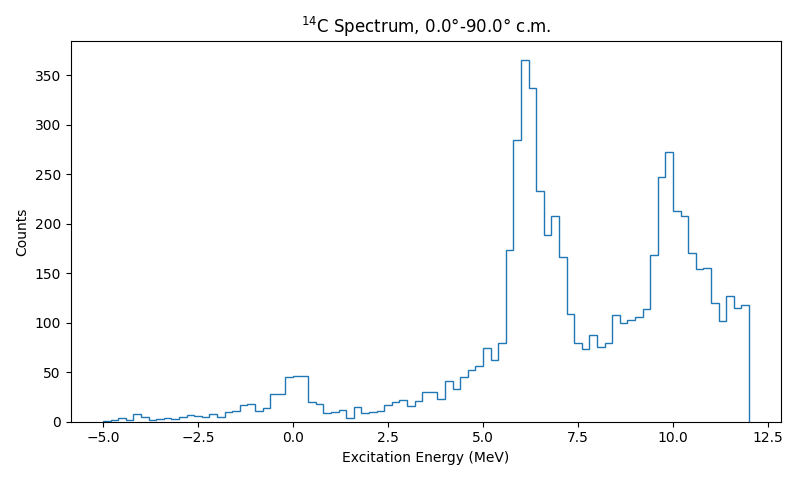

In [8]:
results["Ex"] += -0.18

mask_polar = (results["Polar_CM"] >= np.deg2rad(min_cm)) & (results["Polar_CM"] <= np.deg2rad(max_cm))
ex_energy_gated = results["Ex"][mask_polar]

grammer.add_hist1d("ex",ex_energy_bins, (ex_energy_min, ex_energy_max))
grammer.fill_hist1d("ex", ex_energy_gated)

ex_hist = grammer.get_hist1d("ex")
fig, ax = plt.subplots(1,1)
ax.stairs(ex_hist.counts, edges = ex_hist.bins)
#ax.vlines(np.array([ex_en_min, ex_en_max]), ymin = 0.0, ymax = max(ex_hist.counts), color = "red", linestyle = "dashed", lw = 1)
ax.set_title(f"{residual.get_latex_rep()} Spectrum, {min_cm}\N{DEGREE SIGN}-{max_cm}\N{DEGREE SIGN} c.m.")
ax.set_xlabel("Excitation Energy (MeV)")
ax.set_ylabel("Counts")
#ax.set_yscale("log")
fig.set_figwidth(8.0)
fig.tight_layout()
#plt.savefig("C:/Users/NateM/WorkStuff/Analysis_Imgs/a2091/14C_d2_Spectrum_10_40_cm.png")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


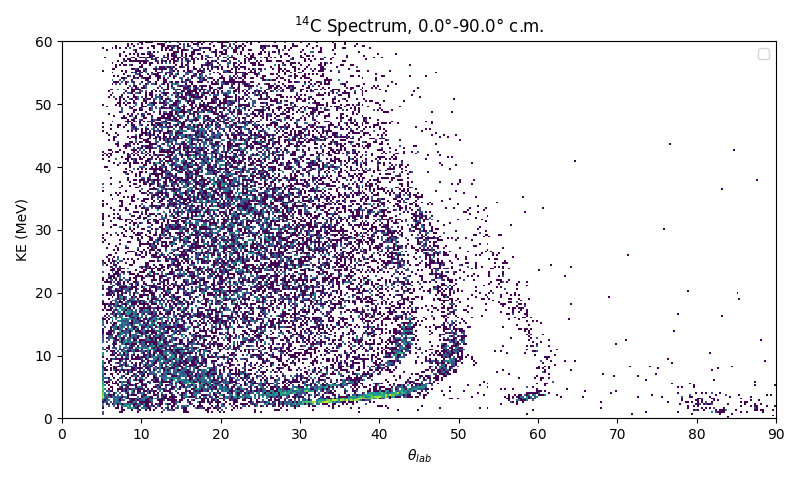

In [9]:
grammer = Histogrammer()

mask_polar = (results["Polar_CM"] >= np.deg2rad(min_cm)) & (results["Polar_CM"] <= np.deg2rad(max_cm))
#ke_gated = results["KE"][mask_polar]
#polar_gated = results["Polar_Lab"][mask_polar] * 180.0 / np.pi
ke_gated = results["KE"]
polar_gated = results["Polar_Lab"] * 180.0 / np.pi

grammer.add_hist2d("kinematics", (360, 200), ((0.0, 90.0), (0.0, 60.0)))
grammer.fill_hist2d("kinematics", polar_gated, ke_gated)

kinematics_hist = grammer.get_hist2d("kinematics")

fig, ax = plt.subplots(1,1)
mesh = ax.pcolormesh(kinematics_hist.x_bins, kinematics_hist.y_bins, kinematics_hist.counts, norm = 'log')
ax.set_title(f"{residual.get_latex_rep()} Spectrum, {min_cm}\N{DEGREE SIGN}-{max_cm}\N{DEGREE SIGN} c.m.")
ax.set_xlabel(r"$\theta_{lab}$")
ax.set_ylabel("KE (MeV)")
ax.set_xlim([0.0, 90.0])
ax.set_ylim([0.0, 60.0])
fig.set_figwidth(8.0)
fig.tight_layout()
ax.legend()

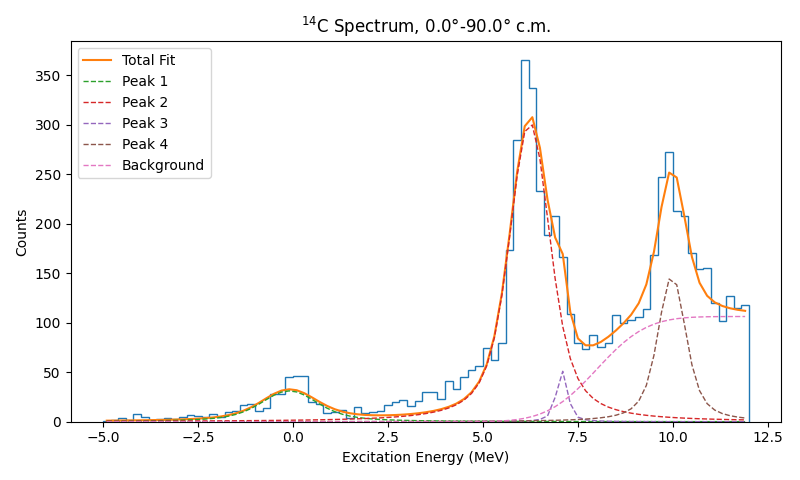

In [10]:
from lmfit.models import *

peak1 = VoigtModel(prefix = "peak1_")
peak1_bins, peak1_counts = ex_hist.get_subrange((-1.04, 0.40))
peak1_bins += 0.5 * ex_hist.bin_width
peak1_weights = np.sqrt(peak1_counts)
peak1_weights = np.divide(1, peak1_weights, out = np.zeros_like(peak1_weights), where = (peak1_weights != 0.0))
pars = peak1.guess(x = peak1_bins, data = peak1_counts, weights = peak1_weights)
pars["peak1_amplitude"].min = 0.0
pars["peak1_center"].min = -0.56
pars["peak1_center"].max = 0.61
pars["peak1_sigma"].max = 0.5

peak2 = VoigtModel(prefix = "peak2_")
#peak2 = GaussianModel(prefix = "peak2_")
peak2_bins, peak2_counts = ex_hist.get_subrange((5.89, 6.49))
peak2_bins += 0.5 * ex_hist.bin_width
peak2_weights = np.sqrt(peak2_counts)
peak2_weights = np.divide(1, peak2_weights, out = np.zeros_like(peak2_weights), where = (peak2_weights != 0.0))
pars.update(peak2.guess(x = peak2_bins, data = peak2_counts, weights = peak2_weights))
pars["peak2_amplitude"].min = 0.0
pars["peak2_center"].min = 5.76
pars["peak2_center"].max = 6.58
pars["peak2_sigma"].max = 1.0

peak3 = VoigtModel(prefix = "peak3_")
#peak3 = GaussianModel(prefix = "peak3_")
peak3_bins, peak3_counts = ex_hist.get_subrange((6.82, 7.82))
peak3_bins += 0.5 * ex_hist.bin_width
peak3_weights = np.sqrt(peak3_counts)
peak3_weights = np.divide(1, peak3_weights, out = np.zeros_like(peak3_weights), where = (peak3_weights != 0.0))
pars.update(peak3.guess(x = peak3_bins, data = peak3_counts, weights = peak3_weights))
pars["peak3_amplitude"].min = 0.0
pars["peak3_center"].min = 7.08
pars["peak3_center"].max = 7.29
pars["peak3_sigma"].max = 0.25

peak4 = VoigtModel(prefix = "peak4_")
peak4_bins, peak4_counts = ex_hist.get_subrange((9.46, 10.46))
peak4_bins += 0.5 * ex_hist.bin_width
peak4_weights = np.sqrt(peak4_counts)
peak4_weights = np.divide(1, peak4_weights, out = np.zeros_like(peak4_weights), where = (peak4_weights != 0.0))
pars.update(peak4.guess(x = peak4_bins, data = peak4_counts, weights = peak4_weights))
pars["peak4_amplitude"].min = 0.0
pars["peak4_center"].min = 9.46
pars["peak4_center"].max = 10.46
pars["peak4_sigma"].max = 0.5

bkg = StepModel(form = "erf", prefix = "bkg_")
bkg_bins, bkg_counts = ex_hist.get_subrange((8.05, 9.44))
bkg_bins += 0.5 * ex_hist.bin_width
bkg_weights = np.sqrt(bkg_counts)
bkg_weights = np.divide(1, bkg_weights, out = np.zeros_like(bkg_weights), where = (bkg_weights != 0.0))
pars.update(bkg.guess(x = bkg_bins, data = bkg_counts, weights = bkg_weights))
#pars["bkg_amplitude"].max = 40
pars["bkg_center"].min = 5.0
pars["bkg_center"].max = 8.0

total_fit = peak1 + peak2 + peak3 + peak4 + bkg
total_bins = ex_hist.bins[:-1] + ex_hist.bin_width/2
total_counts = ex_hist.counts
total_weights = np.sqrt(total_counts)
total_weights = np.divide(1, total_weights, out = np.zeros_like(total_weights), where = (total_weights != 0.0))
total_result = total_fit.fit(params = pars, x = total_bins, data = total_counts, weights = total_weights)

comps = total_result.eval_components()

fig, ax = plt.subplots(1,1)
ax.stairs(ex_hist.counts, edges = ex_hist.bins)
ax.plot(total_bins, total_result.best_fit, label = "Total Fit")
ax.plot(total_bins, comps["peak1_"], lw = 1, linestyle = "dashed", label = "Peak 1")
ax.plot(total_bins, comps["peak2_"], lw = 1, linestyle = "dashed", label = "Peak 2")
ax.plot(total_bins, comps["peak3_"], lw = 1, linestyle = "dashed", label = "Peak 3")
ax.plot(total_bins, comps["peak4_"], lw = 1, linestyle = "dashed", label = "Peak 4")
ax.plot(total_bins, comps["bkg_"], lw = 1, linestyle = "dashed", label = "Background")
ax.set_title(f"{residual.get_latex_rep()} Spectrum, {min_cm}\N{DEGREE SIGN}-{max_cm}\N{DEGREE SIGN} c.m.")
ax.set_xlabel("Excitation Energy (MeV)")
ax.set_ylabel("Counts")
#ax.set_xlim([-2, 9])
ax.legend()
#ax.set_yscale("log")
fig.set_figwidth(8.0)
fig.tight_layout()
#plt.savefig("C:/Users/NateM/WorkStuff/Analysis_Imgs/a2091/14C_p2_Spectrum_fitted.png")

In [11]:
np.linspace(min_cm, max_cm, ang_dist_bins)

array([ 0.        ,  4.73684211,  9.47368421, 14.21052632, 18.94736842,
       23.68421053, 28.42105263, 33.15789474, 37.89473684, 42.63157895,
       47.36842105, 52.10526316, 56.84210526, 61.57894737, 66.31578947,
       71.05263158, 75.78947368, 80.52631579, 85.26315789, 90.        ])

# Make Angular Cuts w/ No Fits

In [12]:
from matplotlib.backends.backend_pdf import PdfPages
from lmfit.models import *

#binset = np.arange(0.0, 180.0, 5.0)
binset = np.linspace(min_cm, max_cm, ang_dist_bins+1)

with PdfPages('C:/Users/NateM/WorkStuff/Analysis_Imgs/a2091/14Cdt_AngCuts.pdf') as pdf:

    grammer2 = Histogrammer()

    mask_polar = (results["Polar_CM"] >= np.deg2rad(min_cm)) & (results["Polar_CM"] <= np.deg2rad(max_cm))
    ex_energy_gated = results["Ex"][mask_polar]
    
    grammer2.add_hist1d("ex", ex_energy_bins, (ex_energy_min, ex_energy_max))
    grammer2.fill_hist1d("ex", ex_energy_gated)
    
    ex_hist = grammer2.get_hist1d("ex")
    fig, ax = plt.subplots(1,1)
    ax.stairs(ex_hist.counts, edges = ex_hist.bins)
    #ax.vlines(np.array([ex_en_min, ex_en_max]), ymin = 0.0, ymax = max(ex_hist.counts), color = "red", linestyle = "dashed", lw = 1)
    ax.set_title(f"{residual.get_latex_rep()} Spectrum, {0.0}\N{DEGREE SIGN}-{180.0}\N{DEGREE SIGN} c.m.")
    ax.set_xlabel("Excitation Energy (MeV)")
    ax.set_ylabel("Counts")
    fig.set_figwidth(8.0)
    fig.tight_layout()
    pdf.savefig()
    plt.close()

    for i in range(len(binset)-1):
        grammer2 = Histogrammer()
        
        mask_polar = (results["Polar_CM"] >= np.deg2rad(binset[i])) & (results["Polar_CM"] <= np.deg2rad(binset[i+1]))
        ex_energy_gated = results["Ex"][mask_polar]
        
        grammer2.add_hist1d("ex", ex_energy_bins, (ex_energy_min, ex_energy_max))
        grammer2.fill_hist1d("ex", ex_energy_gated)
        
        ex_hist = grammer2.get_hist1d("ex")
                
        fig, ax = plt.subplots(1,1)
        ax.stairs(ex_hist.counts, edges = ex_hist.bins)
        #ax.vlines(np.array([ex_en_min, ex_en_max]), ymin = 0.0, ymax = max(ex_hist.counts), color = "red", linestyle = "dashed", lw = 1)
        ax.set_title(f"{residual.get_latex_rep()} Spectrum, {binset[i]}\N{DEGREE SIGN}-{binset[i+1]}\N{DEGREE SIGN} c.m.")
        ax.set_xlabel("Excitation Energy (MeV)")
        ax.set_ylabel("Counts")
        fig.set_figwidth(8.0)
        fig.tight_layout()
        pdf.savefig()

        plt.close()

# Fit Angular Cuts

In [13]:
from matplotlib.backends.backend_pdf import PdfPages
from lmfit.models import *

binset = np.linspace(min_cm, max_cm, ang_dist_bins+1)
zimboop = np.arange(ex_energy_min, ex_energy_max, 0.01)

sub_fits = {}

fit_pars = {"peak1": {"range": (-0.56, 0.61),
                      "amplitude": (0.0, np.inf), 
                      "center": (-0.56, 0.61), 
                      "sigma": (0.01, 0.75)}, 
            "peak2": {"range": (5.76, 6.58), 
                      "amplitude": (0.01, np.inf), 
                      "center": (5.96, 6.58), # 5.76 -> 5.96
                      "sigma": (0.01, 0.25)},
            "peak3": {"range": (6.72, 7.29), 
                      "amplitude": (0.0, np.inf), 
                      "center": (6.87, 7.29), # 6.72 -> 6.87
                      "sigma": (None, None)}, 
            "peak4": {"range": (9.46, 10.46), 
                      "amplitude": (0.0, np.inf), 
                      "center": (9.46, 10.46), 
                      "sigma": (0.0, 0.5)}, 
            "bkg": {"range": (8.05, 9.44), 
                    "amplitude": (0.0, 75.0), 
                    "center": (5.0, 8.0), 
                    "sigma": (1.0, 5.0)},
           }

with PdfPages('C:/Users/NateM/WorkStuff/Analysis_Imgs/a2091/14Cdt_AngCutsFit.pdf') as pdf:

    grammer2 = Histogrammer()

    mask_polar = (results["Polar_CM"] >= np.deg2rad(min_cm)) & (results["Polar_CM"] <= np.deg2rad(max_cm))
    ex_energy_gated = results["Ex"][mask_polar]
    
    grammer2.add_hist1d("ex", ex_energy_bins, (ex_energy_min, ex_energy_max))
    grammer2.fill_hist1d("ex", ex_energy_gated)
    
    ex_hist = grammer2.get_hist1d("ex")

    peak1 = GaussianModel(prefix = "peak1_")
    peak1_bins, peak1_counts = ex_hist.get_subrange(fit_pars["peak1"]["range"])
    peak1_bins += 0.5 * ex_hist.bin_width
    peak1_weights = np.sqrt(peak1_counts)
    peak1_weights = np.divide(1, peak1_weights, out = np.zeros_like(peak1_weights), where = (peak1_weights != 0.0))
    pars = peak1.guess(x = peak1_bins, data = peak1_counts, weights = peak1_weights)
    #pars.update(peak1.guess(x = peak1_bins, data = peak1_counts, weights = peak1_weights))
    pars["peak1_amplitude"].min = fit_pars["peak1"]["amplitude"][0]
    pars["peak1_center"].min = fit_pars["peak1"]["center"][0]
    pars["peak1_center"].max = fit_pars["peak1"]["center"][1]
    pars["peak1_sigma"].max = fit_pars["peak1"]["sigma"][0]
    pars["peak1_sigma"].min = fit_pars["peak1"]["sigma"][1]
    
    peak2 = GaussianModel(prefix = "peak2_")
    peak2_bins, peak2_counts = ex_hist.get_subrange(fit_pars["peak2"]["range"])
    peak2_bins += 0.5 * ex_hist.bin_width
    peak2_weights = np.sqrt(peak2_counts)
    peak2_weights = np.divide(1, peak2_weights, out = np.zeros_like(peak2_weights), where = (peak2_weights != 0.0))
    pars.update(peak2.guess(x = peak2_bins, data = peak2_counts, weights = peak2_weights))
    pars["peak2_amplitude"].min = fit_pars["peak2"]["amplitude"][0]
    pars["peak2_center"].min = fit_pars["peak2"]["center"][0]
    pars["peak2_center"].max = fit_pars["peak2"]["center"][1]
    pars["peak2_sigma"].max = fit_pars["peak2"]["sigma"][0]
    pars["peak2_sigma"].min = fit_pars["peak2"]["sigma"][1]
    
    peak3 = GaussianModel(prefix = "peak3_")
    peak3_bins, peak3_counts = ex_hist.get_subrange(fit_pars["peak3"]["range"])
    peak3_bins += 0.5 * ex_hist.bin_width
    peak3_weights = np.sqrt(peak3_counts)
    peak3_weights = np.divide(1, peak3_weights, out = np.zeros_like(peak3_weights), where = (peak3_weights != 0.0))
    pars.update(peak3.guess(x = peak3_bins, data = peak3_counts, weights = peak3_weights))
    pars["peak3_amplitude"].min = fit_pars["peak3"]["amplitude"][0]
    pars["peak3_center"].min = fit_pars["peak3"]["center"][0]
    pars["peak3_center"].max = fit_pars["peak3"]["center"][1]
    pars["peak3_sigma"].set(expr = "peak2_sigma", vary = False)

    peak4 = VoigtModel(prefix = "peak4_")
    peak4_bins, peak4_counts = ex_hist.get_subrange(fit_pars["peak4"]["range"])
    peak4_bins += 0.5 * ex_hist.bin_width
    peak4_weights = np.sqrt(peak4_counts)
    peak4_weights = np.divide(1, peak4_weights, out = np.zeros_like(peak4_weights), where = (peak4_weights != 0.0))
    pars.update(peak4.guess(x = peak4_bins, data = peak4_counts, weights = peak4_weights))
    pars["peak4_amplitude"].min = fit_pars["peak4"]["amplitude"][0]
    pars["peak4_center"].min = fit_pars["peak4"]["center"][0]
    pars["peak4_center"].max = fit_pars["peak4"]["center"][1]
    pars["peak4_sigma"].max = fit_pars["peak4"]["sigma"][1]

    bkg = StepModel(form = "erf", prefix = "bkg_")
    bkg_bins, bkg_counts = ex_hist.get_subrange(fit_pars["bkg"]["range"])
    bkg_bins += 0.5 * ex_hist.bin_width
    bkg_weights = np.sqrt(bkg_counts)
    bkg_weights = np.divide(1, bkg_weights, out = np.zeros_like(bkg_weights), where = (bkg_weights != 0.0))
    pars.update(bkg.guess(x = bkg_bins, data = bkg_counts, weights = bkg_weights))
    pars["bkg_amplitude"].max = fit_pars["bkg"]["amplitude"][1]
    pars["bkg_center"].min = fit_pars["bkg"]["center"][0]
    pars["bkg_center"].max = fit_pars["bkg"]["center"][1]
    pars["bkg_sigma"].min = fit_pars["bkg"]["sigma"][0]
    pars["bkg_sigma"].max = fit_pars["bkg"]["sigma"][1]
    
    total_fit = peak1 + peak2 + peak3 + peak4 + bkg
    total_bins = ex_hist.bins[:-1] + ex_hist.bin_width/2
    total_counts = ex_hist.counts
    total_weights = np.sqrt(total_counts)
    total_weights = np.divide(1, total_weights, out = np.zeros_like(total_weights), where = (total_weights != 0.0))
    total_result = total_fit.fit(params = pars, x = total_bins, data = total_counts, weights = total_weights)
    
    comps = total_result.eval_components()
    
    fig, ax = plt.subplots(1,1)
    ax.stairs(ex_hist.counts, edges = ex_hist.bins)
    ax.plot(zimboop, total_result.eval(x = zimboop), label = "Total Fit")
    ax.plot(zimboop, total_result.eval_components(x = zimboop)["peak1_"], linestyle = "dashed", label = "Peak 1")
    ax.plot(zimboop, total_result.eval_components(x = zimboop)["peak2_"], linestyle = "dashed", label = "Peak 2")
    ax.plot(zimboop, total_result.eval_components(x = zimboop)["peak3_"], linestyle = "dashed", label = "Peak 3")
    ax.plot(zimboop, total_result.eval_components(x = zimboop)["peak4_"], linestyle = "dashed", label = "Peak 4")
    ax.plot(zimboop, total_result.eval_components(x = zimboop)["bkg_"], linestyle = "dashed", label = "Background")

    ax.set_title(f"{residual.get_latex_rep()} Spectrum, {0.0}\N{DEGREE SIGN}-{180.0}\N{DEGREE SIGN} c.m.")
    ax.set_xlabel("Excitation Energy (MeV)")
    ax.set_ylabel("Counts")
    ax.legend()
    fig.set_figwidth(8.0)
    fig.tight_layout()
    pdf.savefig()
    plt.close()

    for i in range(len(binset)-1):
        sub_fit_title = f"{binset[i]}-{binset[i+1]}"
        
        grammer2 = Histogrammer()
        
        mask_polar = (results["Polar_CM"] >= np.deg2rad(binset[i])) & (results["Polar_CM"] <= np.deg2rad(binset[i+1]))
        ex_energy_gated = results["Ex"][mask_polar]
        
        grammer2.add_hist1d("ex", ex_energy_bins, (ex_energy_min, ex_energy_max))
        grammer2.fill_hist1d("ex", ex_energy_gated)
        
        ex_hist = grammer2.get_hist1d("ex")

        peak1 = GaussianModel(prefix = "peak1_")
        peak1_bins, peak1_counts = ex_hist.get_subrange(fit_pars["peak1"]["range"])
        peak1_bins += 0.5 * ex_hist.bin_width
        peak1_weights = np.sqrt(peak1_counts)
        peak1_weights = np.divide(1, peak1_weights, out = np.zeros_like(peak1_weights), where = (peak1_weights != 0.0))
        #pars = peak1.guess(x = peak1_bins, data = peak1_counts, weights = peak1_weights)
        pars.update(peak1.guess(x = peak1_bins, data = peak1_counts, weights = peak1_weights))
        pars["peak1_amplitude"].min = fit_pars["peak1"]["amplitude"][0]
        pars["peak1_center"].min = fit_pars["peak1"]["center"][0]
        pars["peak1_center"].max = fit_pars["peak1"]["center"][1]
        pars["peak1_sigma"].max = fit_pars["peak1"]["sigma"][0]
        pars["peak1_sigma"].min = fit_pars["peak1"]["sigma"][1]
        
        peak2 = GaussianModel(prefix = "peak2_")
        peak2_bins, peak2_counts = ex_hist.get_subrange(fit_pars["peak2"]["range"])
        peak2_bins += 0.5 * ex_hist.bin_width
        peak2_weights = np.sqrt(peak2_counts)
        peak2_weights = np.divide(1, peak2_weights, out = np.zeros_like(peak2_weights), where = (peak2_weights != 0.0))
        pars.update(peak2.guess(x = peak2_bins, data = peak2_counts, weights = peak2_weights))
        pars["peak2_amplitude"].min = fit_pars["peak2"]["amplitude"][0]
        pars["peak2_center"].min = fit_pars["peak2"]["center"][0]
        pars["peak2_center"].max = fit_pars["peak2"]["center"][1]
        pars["peak2_sigma"].max = fit_pars["peak2"]["sigma"][0]
        pars["peak2_sigma"].min = fit_pars["peak2"]["sigma"][1]
        
        peak3 = GaussianModel(prefix = "peak3_")
        peak3_bins, peak3_counts = ex_hist.get_subrange(fit_pars["peak3"]["range"])
        peak3_bins += 0.5 * ex_hist.bin_width
        peak3_weights = np.sqrt(peak3_counts)
        peak3_weights = np.divide(1, peak3_weights, out = np.zeros_like(peak3_weights), where = (peak3_weights != 0.0))
        pars.update(peak3.guess(x = peak3_bins, data = peak3_counts, weights = peak3_weights))
        pars["peak3_amplitude"].min = fit_pars["peak3"]["amplitude"][0]
        pars["peak3_center"].min = fit_pars["peak3"]["center"][0]
        pars["peak3_center"].max = fit_pars["peak3"]["center"][1]
        pars["peak3_sigma"].set(expr = "peak2_sigma", vary = False)

        peak4 = VoigtModel(prefix = "peak4_")
        peak4_bins, peak4_counts = ex_hist.get_subrange(fit_pars["peak4"]["range"])
        peak4_bins += 0.5 * ex_hist.bin_width
        peak4_weights = np.sqrt(peak4_counts)
        peak4_weights = np.divide(1, peak4_weights, out = np.zeros_like(peak4_weights), where = (peak4_weights != 0.0))
        pars.update(peak4.guess(x = peak4_bins, data = peak4_counts, weights = peak4_weights))
        pars["peak4_amplitude"].min = fit_pars["peak4"]["amplitude"][0]
        pars["peak4_center"].min = fit_pars["peak4"]["center"][0]
        pars["peak4_center"].max = fit_pars["peak4"]["center"][1]
        pars["peak4_sigma"].max = fit_pars["peak4"]["sigma"][1]

        bkg = StepModel(form = "erf", prefix = "bkg_")
        bkg_bins, bkg_counts = ex_hist.get_subrange(fit_pars["bkg"]["range"])
        bkg_bins += 0.5 * ex_hist.bin_width
        bkg_weights = np.sqrt(bkg_counts)
        bkg_weights = np.divide(1, bkg_weights, out = np.zeros_like(bkg_weights), where = (bkg_weights != 0.0))
        pars.update(bkg.guess(x = bkg_bins, data = bkg_counts, weights = bkg_weights))
        pars["bkg_amplitude"].max = fit_pars["bkg"]["amplitude"][1]
        pars["bkg_center"].min = fit_pars["bkg"]["center"][0]
        pars["bkg_center"].max = fit_pars["bkg"]["center"][1]
        pars["bkg_sigma"].min = fit_pars["bkg"]["sigma"][0]
        pars["bkg_sigma"].max = fit_pars["bkg"]["sigma"][1]
        
        total_fit = peak1 + peak2 + peak3 + peak4 + bkg
        total_bins = ex_hist.bins[:-1] + ex_hist.bin_width/2
        total_counts = ex_hist.counts
        total_weights = np.sqrt(total_counts)
        total_weights = np.divide(1, total_weights, out = np.zeros_like(total_weights), where = (total_weights != 0.0))
        total_result = total_fit.fit(params = pars, x = total_bins, data = total_counts, weights = total_weights)

        sub_fits[sub_fit_title] = total_result
        
        comps = total_result.eval_components()
        
        fig, ax = plt.subplots(1, 1)
        ax.stairs(ex_hist.counts, edges = ex_hist.bins)
        ax.plot(zimboop, total_result.eval(x = zimboop), label = "Total Fit")
        ax.plot(zimboop, total_result.eval_components(x = zimboop)["peak1_"], linestyle = "dashed", label = "Peak 1")
        ax.plot(zimboop, total_result.eval_components(x = zimboop)["peak2_"], linestyle = "dashed", label = "Peak 2")
        ax.plot(zimboop, total_result.eval_components(x = zimboop)["peak3_"], linestyle = "dashed", label = "Peak 3")
        ax.plot(zimboop, total_result.eval_components(x = zimboop)["peak4_"], linestyle = "dashed", label = "Peak 4")
        ax.plot(zimboop, total_result.eval_components(x = zimboop)["bkg_"], linestyle = "dashed", label = "Background")
        
        ax.set_title(f"{residual.get_latex_rep()} Spectrum, {binset[i]}\N{DEGREE SIGN}-{binset[i+1]}\N{DEGREE SIGN} c.m.")
        ax.set_xlabel("Excitation Energy (MeV)")
        ax.set_ylabel("Counts")
        ax.legend()
        fig.set_figwidth(8.0)
        fig.tight_layout()
        pdf.savefig()

        plt.close()

In [14]:
cm_counts = {}

for peak in ["peak1_", "peak2_", "peak3_", "peak4_"]:
    counts_i = []
    for cm_bin in sub_fits.keys():
        counts_i.append(np.sum(sub_fits[cm_bin].eval_components()[peak]))

    cm_counts[peak] = np.array(counts_i)

grammer.add_hist1d("polar_cm", ang_dist_bins, (min_cm, max_cm))
cm_hist = grammer.get_hist1d("polar_cm")

# Select Peak to Analyze

In [15]:
state_to_analyze = 0
peak_to_analyze = "peak1_"
jpi_to_analyze = "$0^+$"

# Extract Scalers For Normalization

In [16]:
scaler_path = WindowsPath("D:/a2091/Workspace_d/Pointcloud/")
estimation_result_path = WindowsPath("D:/a2091/Workspace_d/GainMatch/")

beam_count = 0

for run in range(run_min, run_max+1):

    # Load in the scaler dataframe and correct the ic_ds according to the dead time
    scaler_df_path = scaler_path / f"{form_run_string(run)}_scaler.parquet"
    if not scaler_df_path.exists():
        continue
    scaler_df = pl.read_parquet(scaler_df_path)
    scaler_df = scaler_df.with_columns((pl.col("ic_ds")*pl.col("trigger_live")/pl.col("trigger_free")).alias("ic_ds_adj"))
    scaler_df = scaler_df.select(pl.col("ic_ds_adj").drop_nans())
    unadj_beam_count_i = scaler_df.select(pl.sum("ic_ds_adj")).item()

    # Calculate the beam purity correction
    estimate_df_path = estimation_result_path / f"{form_run_string(run)}.parquet"
    if not estimate_df_path.exists():
        continue
    estimate_df = pl.scan_parquet(estimate_df_path)
    estimate_df_gated = estimate_df.filter((pl.col('ic_amplitude') > ic_min_val) & (pl.col('ic_amplitude') < ic_max_val))
    estimate_df = estimate_df.collect()
    estimate_df_gated = estimate_df_gated.collect()

    # Apply the beam purity correction
    adj_beam_count_i = unadj_beam_count_i * (len(estimate_df_gated) / len(estimate_df))

    beam_count += adj_beam_count_i

beam_count *= 1000

# Extract Simulation Results For Efficiency Correction

In [17]:
sim_path_head = WindowsPath(f"D:/a2091/Simulations/15Cdt_{state_to_analyze}")

sim_result_path = sim_path_head / "Workspace/InterpSolver/"
sim_run_min = 0
sim_run_max = 0

sim_grammer = Histogrammer()
sim_grammer.add_hist2d('ke_theta', (360, 1600), ((0.0, 180.0), (0.0, 80.0)))
sim_grammer.add_hist2d('ke_phi', (360, 1600), ((0.0, 360.0), (0.0, 80.0)))
sim_grammer.add_hist1d('ex', ex_energy_bins, (ex_energy_min, ex_energy_max))

sim_results = {}
sim_results["Polar_CM"] = np.empty(0, float)
sim_results["Ex"] = np.empty(0, float)

kinetics = np.empty(0, float)
angles = np.empty(0, float)
chisq = np.empty(0, float)
target_vector = vector.array({"px": [0.0], "py": [0.0], "pz": [0.0], "E": [target.mass]})
for run in range(sim_run_min, sim_run_max+1):
    sim_df = None
    sim_path = sim_result_path / f"run_{run:04d}_{ejectile.isotopic_symbol}.parquet"
    if not sim_path.exists():
        continue
    sim_df = pl.scan_parquet(sim_path)

    #df = df.filter((pl.col('redchisq') < 1.65))
    sim_df = sim_df.filter((pl.col("vertex_z") > min_z) & (pl.col("vertex_z") < max_z)).collect()
    
    # Construct the projectile vectors (beam)
    vertices = sim_df.select(['vertex_x', 'vertex_y', 'vertex_z']).to_numpy()
    distances = np.linalg.norm(vertices, axis=1)
    projectile_ke = proj_energy_start - target_material.get_energy_loss(projectile, proj_energy_start, distances)
    projectile_vector = vector.array({
        "px": np.zeros(len(projectile_ke)),
        "py": np.zeros(len(projectile_ke)),
        "pz": np.sqrt(projectile_ke * (projectile_ke + 2.0 * projectile.mass)),
        "E": projectile_ke + projectile.mass
    })

    # Construct the ejectile vectors (detected)
    brho = sim_df.select('brho').to_numpy().flatten()
    momentum = sim_df.select('brho').to_numpy().flatten() * float(ejectile.Z) * QBRHO_2_P
    kinetic_energy = np.sqrt(momentum**2.0 + ejectile.mass**2.0) - ejectile.mass
    polar = sim_df.select('polar').to_numpy().flatten()
    az = sim_df.select('azimuthal').to_numpy().flatten()
    cs = sim_df.select('redchisq').to_numpy().flatten()
    ejectile_vector = vector.array({
        "px": momentum * np.sin(polar) * np.cos(az),
        "py": momentum * np.sin(polar) * np.sin(az),
        "pz": momentum * np.cos(polar),
        "E": np.sqrt(momentum**2.0 + ejectile.mass**2.0)
    })

    # Do the kinematics
    residual_vector = target_vector + projectile_vector - ejectile_vector # type: ignore

    cm_vec = ejectile_vector.boostCM_of(projectile_vector + target_vector)
    polar_cm = np.pi - cm_vec.theta
    ex = residual_vector.mass - residual.mass

    sim_results["Polar_CM"] = np.append(sim_results["Polar_CM"], polar_cm)
    sim_results["Ex"] = np.append(sim_results["Ex"], ex)

Overwriting histogram named ex in Histogrammer.add_histogram!


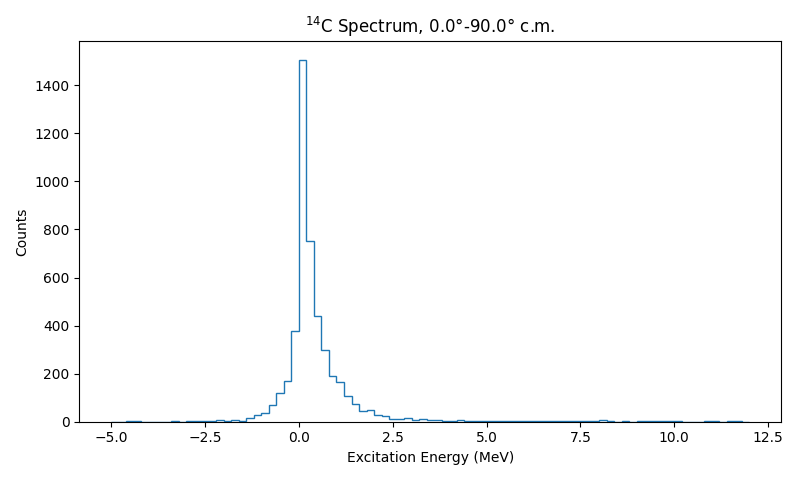

In [18]:
mask_polar = (sim_results["Polar_CM"] >= np.deg2rad(min_cm)) & (sim_results["Polar_CM"] <= np.deg2rad(max_cm))
ex_energy_gated = sim_results["Ex"][mask_polar]

sim_grammer.add_hist1d("ex", ex_energy_bins, (ex_energy_min, ex_energy_max))
sim_grammer.fill_hist1d("ex", ex_energy_gated)

sim_ex_hist = sim_grammer.get_hist1d("ex")
fig, ax = plt.subplots(1,1)
ax.stairs(sim_ex_hist.counts, edges = sim_ex_hist.bins)
#ax.vlines(np.array([ex_en_min, ex_en_max]), ymin = 0.0, ymax = max(sim_ex_hist.counts), color = "red", linestyle = "dashed", lw = 1)
ax.set_title(f"{residual.get_latex_rep()} Spectrum, {min_cm}\N{DEGREE SIGN}-{max_cm}\N{DEGREE SIGN} c.m.")
ax.set_xlabel("Excitation Energy (MeV)")
ax.set_ylabel("Counts")
fig.set_figwidth(8.0)
fig.tight_layout()

In [19]:
sim_kine_path = sim_path_head / "output/kinematics/kinematics.parquet"
sim_kine = pl.scan_parquet(sim_kine_path)

beam_coords = (
    sim_kine.filter((pl.col("Z") == projectile.Z) & (pl.col("A") == projectile.A))
    .select("px", "py", "pz", "energy")
    .collect()
    .to_numpy()
)
beam_vectors = vector.array(
    {
        "px": beam_coords[:, 0],
        "py": beam_coords[:, 1],
        "pz": beam_coords[:, 2],
        "E": beam_coords[:, 3],
    }
)
product_coords = (
    sim_kine.filter((pl.col("Z") == residual.Z) & (pl.col("A") == residual.A))
    .select("px", "py", "pz", "energy")
    .collect()
    .to_numpy()
)
product_vectors = vector.array(
    {
        "px": product_coords[:, 0],
        "py": product_coords[:, 1],
        "pz": product_coords[:, 2],
        "E": product_coords[:, 3],
    }
)

sim_cm_in = product_vectors.boostCM_of(beam_vectors + target_vector).theta
sim_grammer.add_hist1d("polar_cm_in", ang_dist_bins, (min_cm, max_cm))
sim_grammer.fill_hist1d("polar_cm_in", np.rad2deg(sim_cm_in))
sim_cm_in = grammer.get_hist1d("cm_polar_sim_all")

#mask_ex = (sim_results["Ex"] >= ex_en_min) & (sim_results["Ex"] < ex_en_max)    # Make note of asymmetric inequalites for binning!
sim_cm_polar_gated = sim_results["Polar_CM"]#[mask_ex]

sim_grammer.add_hist1d("polar_cm_out", ang_dist_bins, (min_cm, max_cm))
sim_grammer.fill_hist1d("polar_cm_out", np.rad2deg(sim_cm_polar_gated))

hist_in = sim_grammer.get_hist1d("polar_cm_in")
hist_out = sim_grammer.get_hist1d("polar_cm_out")

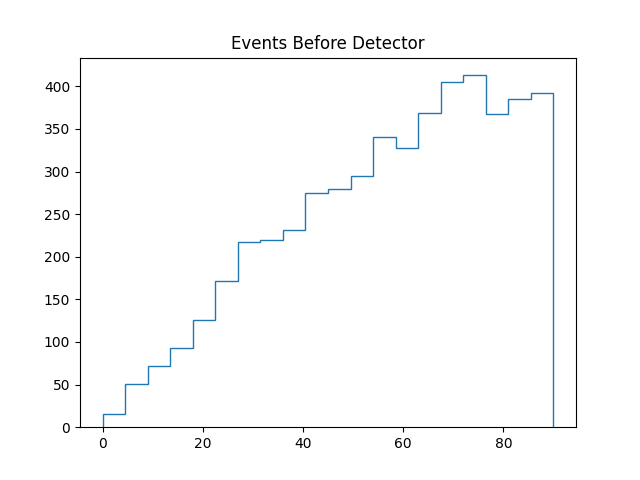

In [20]:
plt.figure()
plt.stairs(hist_in.counts, edges = hist_in.bins)
plt.title("Events Before Detector")
plt.show()

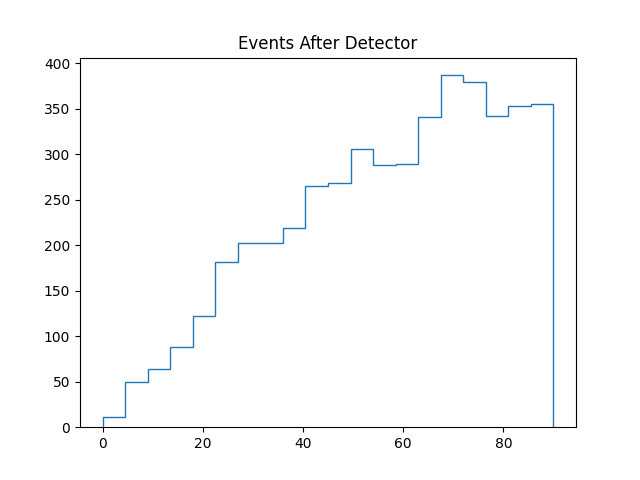

4684


In [21]:
plt.figure()
plt.stairs(hist_out.counts, edges = hist_out.bins)
plt.title("Events After Detector")
plt.show()

print(sum(sim_ex_hist.counts))

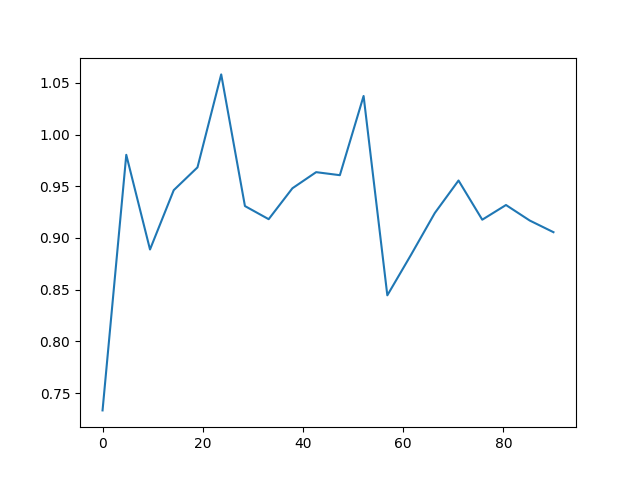

In [22]:
plt.figure()
plt.plot(np.linspace(min_cm, max_cm, ang_dist_bins), hist_out.counts / hist_in.counts)
plt.show()

# Apply All Corrections

In [23]:
length = max_z - min_z    # Units of meters
nuclei_areal_density = pressure * torr_2_pascal * length / boltzmann / temperature * stoich * 1.0e-31

cm_hist = grammer.get_hist1d("polar_cm")
bins = cm_hist.bins
bin_width = cm_hist.bin_width

solid_angle_corr = 1 / (np.diff(np.cos(np.deg2rad(bins))) * -2 * np.pi)
beam_count_corr = 1 / beam_count
nuclei_areal_density_corr = 1 / nuclei_areal_density

eff_corr = hist_in.counts / hist_out.counts

countycounts = cm_counts[peak_to_analyze]

xs = countycounts * solid_angle_corr * beam_count_corr * nuclei_areal_density_corr * eff_corr

err = xs * np.sqrt((1/countycounts) + np.sqrt((1/hist_in.counts) + (1/hist_out.counts)))

C:\Users\NateM\AppData\Local\Temp\ipykernel_12592\3477356991.py:18: RuntimeWarning: divide by zero encountered in divide
  err = xs * np.sqrt((1/countycounts) + np.sqrt((1/hist_in.counts) + (1/hist_out.counts)))
C:\Users\NateM\AppData\Local\Temp\ipykernel_12592\3477356991.py:18: RuntimeWarning: invalid value encountered in multiply
  err = xs * np.sqrt((1/countycounts) + np.sqrt((1/hist_in.counts) + (1/hist_out.counts)))


# Load in DWBA Calculation

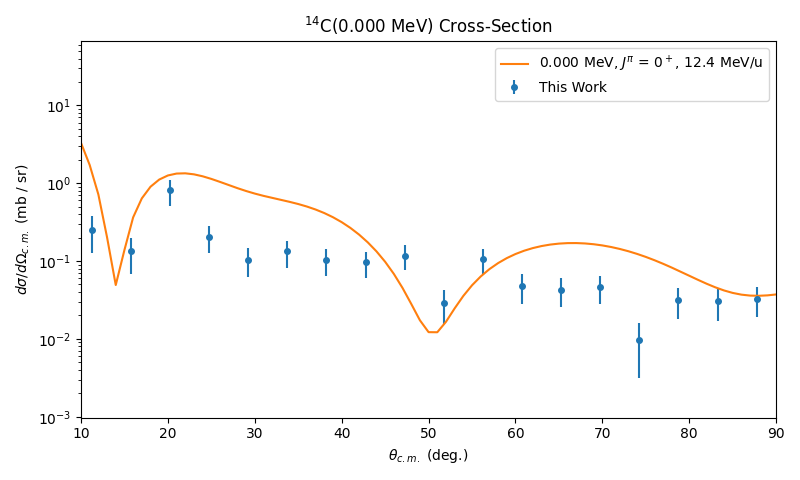

In [24]:
dwba_path = WindowsPath(f"C:/Users/NateM/WorkStuff/Analysis/Ptolemy/15Cdt/{state_to_analyze}/14C_{state_to_analyze}.txt")
dwba = np.loadtxt(dwba_path, skiprows = 2)
dwba_theta = dwba[:, 0]
dwba_cross = dwba[:, 1]

jie_path = WindowsPath("D:/a2091/JieHELIOSData/15Cdt_gs.txt")
jie_data = np.loadtxt(jie_path, skiprows = 1)
jie_theta = jie_data[:, 0]
jie_cross = jie_data[:, 1]
jie_err = jie_data[:, 2]

fig, ax = plt.subplots(1,1)
ax.errorbar(bins[:-1]+bin_width/2, xs, yerr = err, markersize = 4, fmt = "o", label = "This Work")
#ax.errorbar(jie_theta, jie_cross, yerr = jie_err, markersize = 4, fmt = "o", label = "Jie")
ax.plot(dwba_theta, dwba_cross, label = rf"{state_to_analyze/1000:.3f} MeV, $J^\pi$ = {jpi_to_analyze}, 12.4 MeV/u")
ax.set_title(f"{residual.get_latex_rep()}({state_to_analyze/1000:.3f} MeV) Cross-Section")
ax.set_xlabel(r"$\theta_{c.m.}$ (deg.)")
ax.set_ylabel(r"$d\sigma / d\Omega_{c.m.}$ (mb / sr)")
ax.set_yscale("log")
ax.legend()
#plt.xlim(min_cm, max_cm)
plt.xlim(10, 90)
#plt.ylim(4e-2, 1e2)
plt.ylim(min(dwba_cross) / 2, max(dwba_cross) * 2)
fig.set_figwidth(8.0)
fig.tight_layout()

# Fit Theoretical to Data for Spec Factor

SF = 0.602137, SF_err = 2.49787


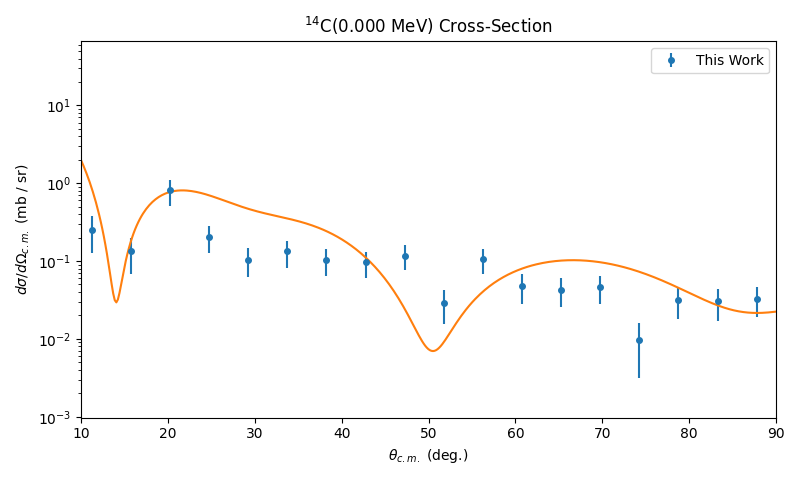

In [25]:
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d, CubicSpline

f1 = CubicSpline(dwba_theta, dwba_cross)

def curve(x, a):
    return a * f1(x)

x = bins[:-1]+bin_width/2
y = xs
yerr = 1/err

theta_fit_min = 15
theta_fit_max = 60

y = y[np.logical_and(x > theta_fit_min, x < theta_fit_max)]
yerr = yerr[np.logical_and(x > theta_fit_min, x < theta_fit_max)]
x = x[np.logical_and(x > theta_fit_min, x < theta_fit_max)]

popt, pcov = curve_fit(curve, x, y, sigma = yerr, absolute_sigma = True, bounds = (0, np.inf), p0 = [1])
print(rf"SF = {popt[0]:.06}, SF_err = {np.sqrt(pcov[0,0]):.06}")

fig, ax = plt.subplots(1,1)
ax.errorbar(bins[:-1]+bin_width/2, xs, yerr = err, markersize = 4, fmt = "o", label = "This Work")
#ax.plot(dwba_theta, dwba_cross, label = rf"{state_to_analyze/1000:.3f} MeV, $J^\pi$ = {jpi_to_analyze}, 12.4 MeV/u")
ax.plot(np.linspace(0, 90, 500), curve(np.linspace(0, 90, 500), *popt))
ax.set_title(f"{residual.get_latex_rep()}({state_to_analyze/1000:.3f} MeV) Cross-Section")
ax.set_xlabel(r"$\theta_{c.m.}$ (deg.)")
ax.set_ylabel(r"$d\sigma / d\Omega_{c.m.}$ (mb / sr)")
ax.set_yscale("log")
ax.legend()
#plt.xlim(min_cm, max_cm)
plt.xlim(10, 90)
#plt.ylim(4e-2, 1e2)
plt.ylim(min(dwba_cross) / 2, max(dwba_cross) * 2)
fig.set_figwidth(8.0)
fig.tight_layout()

# Plot Additional States

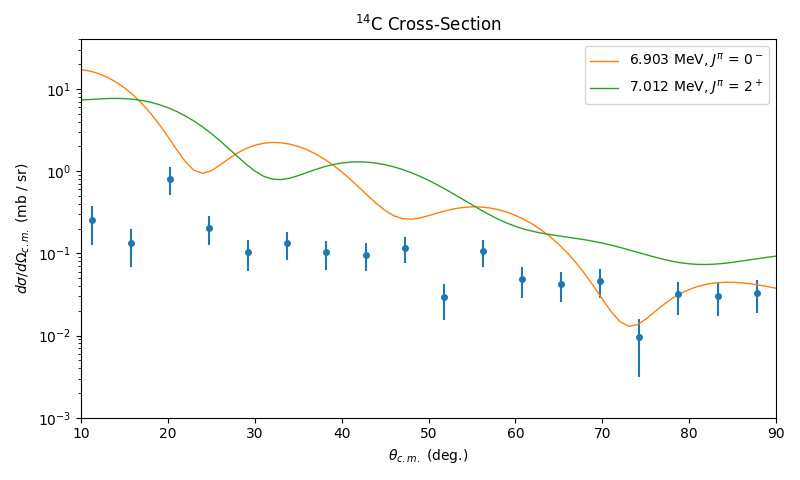

In [26]:
#states_to_check = np.array([9746, 9801, 10425, 10498]) # Unbound resonances
#states_to_check = np.array([6093, 6589, 6728]) # Possible states for second peak
#Jpi = np.array([r"$1^-$", r"$0^+$", r"$3^-$"])
states_to_check = np.array([6903, 7012]) # Possible states for mystery third peak
Jpi = np.array([r"$0^-$", r"$2^+$"])

fig, ax = plt.subplots(1,1)
ax.errorbar(bins[:-1]+bin_width/2, xs, yerr = err, markersize = 4, fmt = "o")
for idx, E_i in enumerate(states_to_check):
    dwba_path = WindowsPath("C:/Users/NateM/WorkStuff/Analysis/Ptolemy/15Cdt")
    dwba_path = dwba_path / f"{E_i}/14C_{E_i}.txt"
    
    dwba = np.loadtxt(dwba_path, skiprows = 2)
    dwba_theta = dwba[:, 0]
    dwba_cross = dwba[:, 1]
    
    ax.plot(dwba_theta, dwba_cross, label = rf"{E_i/1000} MeV, $J^\pi$ = {Jpi[idx]}", lw = 1)
ax.set_title(f"{residual.get_latex_rep()} Cross-Section")
ax.set_xlabel(r"$\theta_{c.m.}$ (deg.)")
ax.set_ylabel(r"$d\sigma / d\Omega_{c.m.}$ (mb / sr)")
ax.set_yscale("log")
ax.legend()
#plt.xlim(min_cm, max_cm)
plt.xlim(10, 90)
plt.ylim(1e-3, 4e1)
#plt.ylim(min(dwba_cross) / 2, max(dwba_cross) * 2)
#plt.ylim(min(dwba_cross) / 2, max(dwba_cross) * 2)
fig.set_figwidth(8.0)
fig.tight_layout()
#plt.savefig("C:/Users/NateM/WorkStuff/Analysis_Imgs/a2091/14C_6903_CrossSection_Corrected.png")

# Multipole Decomposition Analysis (MDA)

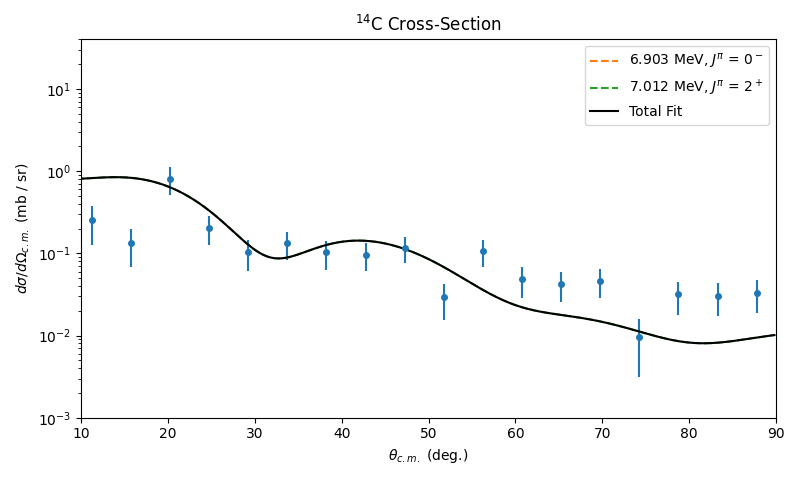

In [32]:
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d, CubicSpline

x = bins[:-1]+bin_width/2
y = xs
yerr = 1/err

y = y[np.logical_and(x > 10, x < 50)]
yerr = yerr[np.logical_and(x > 10, x < 50)]
x = x[np.logical_and(x > 10, x < 50)]

xgrid = np.arange(0, 90, 0.2)

dwba_path = WindowsPath("C:/Users/NateM/WorkStuff/Analysis/Ptolemy/15Cdt")
dwba_path = dwba_path / f"6903/14C_6903.txt"
dwba = np.loadtxt(dwba_path, skiprows = 2)
dwba_theta = dwba[:, 0]
dwba_cross = dwba[:, 1]
f1 = CubicSpline(dwba_theta, dwba_cross)

dwba_path = WindowsPath("C:/Users/NateM/WorkStuff/Analysis/Ptolemy/15Cdt")
dwba_path = dwba_path / f"7012/14C_7012.txt"
dwba = np.loadtxt(dwba_path, skiprows = 2)
dwba_theta = dwba[:, 0]
dwba_cross = dwba[:, 1]
f2 = CubicSpline(dwba_theta, dwba_cross)

def curve(x, a1, a2):
    return a1*f1(x) + a2*f2(x)

popt, pcov = curve_fit(curve, x, y, 
                       sigma = yerr, absolute_sigma = True,
                       bounds = (0, np.inf), 
                       p0 = [1, 1],
                      )

fig, ax = plt.subplots(1,1)
ax.errorbar(bins[:-1]+bin_width/2, xs, yerr = err, markersize = 4, fmt = "o")
ax.plot(xgrid, popt[0]*f1(xgrid), "--", label = r"6.903 MeV, $J^\pi$ = $0^-$")
ax.plot(xgrid, popt[1]*f2(xgrid), "--", label = r"7.012 MeV, $J^\pi$ = $2^+$")
ax.plot(xgrid, curve(xgrid, *popt), "k", label = "Total Fit")
ax.set_title(f"{residual.get_latex_rep()} Cross-Section")
ax.set_xlabel(r"$\theta_{c.m.}$ (deg.)")
ax.set_ylabel(r"$d\sigma / d\Omega_{c.m.}$ (mb / sr)")
ax.set_yscale("log")
ax.legend()
plt.xlim(10, 90)
plt.ylim(1e-3, 4e1)
fig.set_figwidth(8.0)
fig.tight_layout()

In [28]:
popt

array([2.82313565e-11, 3.87137221e-02])

In [29]:
np.sqrt(np.diagonal(pcov))

array([0.01205773, 0.01633502])

# Check PID and Kinematics for Certain Angles

Reaction: 2H(15C, 3H)14C


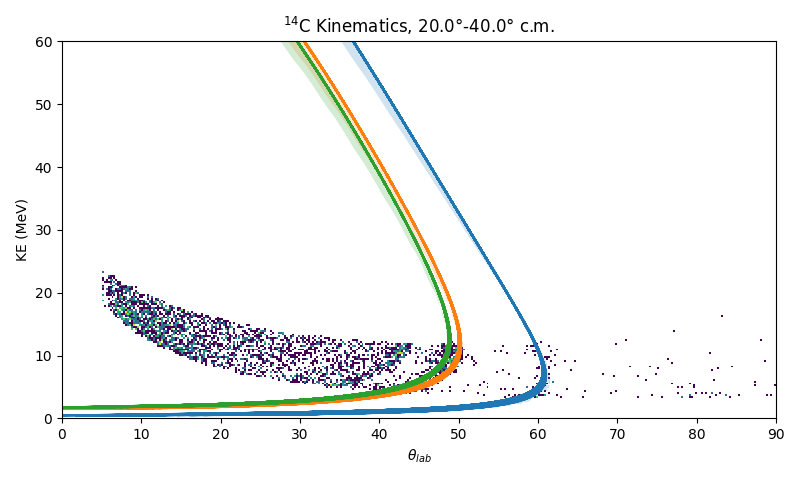

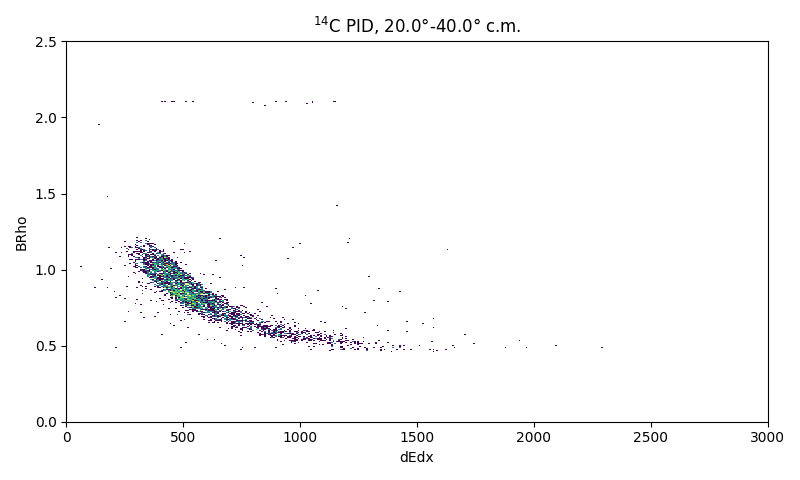

In [31]:
cm_min_mask = 20.0
cm_max_mask = 40.0

dfa = pl.from_dict(results)
dfb = dfa.filter((pl.col("Polar_CM") > np.deg2rad(cm_min_mask)) & (pl.col("Polar_CM") < np.deg2rad(cm_max_mask)))

grammer = Histogrammer()

grammer.add_hist2d("kinematics", (360, 200), ((0.0, 90.0), (0.0, 60.0)))
grammer.fill_hist2d("kinematics", np.rad2deg(dfb["Polar_Lab"].to_numpy()), dfb["KE"].to_numpy())
grammer.add_hist2d("pid", (400, 400), ((0, 3e3), (0, 2.5)))
grammer.fill_hist2d("pid", dfb["dEdx"].to_numpy(), dfb["brho"].to_numpy())

kinematics_hist = grammer.get_hist2d("kinematics")
pid_hist = grammer.get_hist2d("pid")

fig, ax = plt.subplots(1, 1)
mesh = ax.pcolormesh(kinematics_hist.x_bins, kinematics_hist.y_bins, kinematics_hist.counts, norm = 'log')
plot_kinematics(target_material_path = target_material_path, 
                ejectile_z = ejectile_z, ejectile_a = ejectile_a, 
                projectile_z = projectile_z, projectile_a = projectile_a, 
                target_z = target_z, target_a = target_a, 
                cm_ang_min = 0.0, cm_ang_max = 180.0,
                proj_energy_start = proj_energy_start, 
                residual_excitations = [0.0, 6.093, 6.903],
                fig = fig, ax = ax, 
                yaxis = "KE")
ax.set_title(f"{residual.get_latex_rep()} Kinematics, {cm_min_mask}\N{DEGREE SIGN}-{cm_max_mask}\N{DEGREE SIGN} c.m.")
ax.set_xlabel(r"$\theta_{lab}$")
ax.set_ylabel("KE (MeV)")
ax.set_xlim([0.0, 90.0])
ax.set_ylim([0.0, 60.0])
fig.set_figwidth(8.0)
fig.tight_layout()
#ax.legend()

fig, ax = plt.subplots(1, 1)
mesh = ax.pcolormesh(pid_hist.x_bins, pid_hist.y_bins, pid_hist.counts, norm = "log")
ax.set_title(f"{residual.get_latex_rep()} PID, {cm_min_mask}\N{DEGREE SIGN}-{cm_max_mask}\N{DEGREE SIGN} c.m.")
ax.set_xlabel("dEdx")
ax.set_ylabel("BRho")
ax.set_xlim([0.0, 3e3])
ax.set_ylim([0.0, 2.5])
fig.set_figwidth(8.0)
fig.tight_layout()